In [ ]:
#importing required libraries
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report



In [ ]:
# ====================== # Setup project paths to allow importing custom modules and accessing data. ====================== #
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

print(f"Project root set to: {PROJECT_ROOT}")
print(f"src folder found: {(PROJECT_ROOT / 'src').exists()}\n")


Project root set to: c:\Users\forda\OneDrive\Desktop\Ambiguity_detection
src folder found: True



In [3]:
from src.data_loader import load_data
from src.utils import rule_based_ambiguity, compute_metrics
from src.model import LABEL_MAP



In [4]:
# ====================== CONFIGURATION ======================
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")

print("Setup completed!\n")



Setup completed!



In [ ]:
# ====================== 1. LOAD DATASET ======================
print("1. Loading Dataset...")
df = load_data("data/dataset.csv")      

print(f"\nTotal requirements loaded: {len(df):,}")
print("\nLabel Distribution:")
print(df['label'].value_counts())

print("\nFirst 3 rows:")
print(df.head(3))

1. Loading Dataset...
Successfully loaded with encoding: latin1
Loaded 7,060 rows
File path: c:\Users\forda\OneDrive\Desktop\Ambiguity_detection\data\dataset.csv
Columns: ['The general purpose of the steam boiler system is to ensure each safe operation of the steam boiler.', '3']

Final cleaned shape: (6809, 2)
Unique labels: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Total requirements loaded: 6,809

Label Distribution:
label
6    3848
5     819
2     599
3     596
4     481
1     466
Name: count, dtype: int64

First 3 rows:
                                                text  label
0  The steam boiler operates safely if the contai...      3
1  Basically, the steam boiler system consists of...      2
2  During operation, the water level is kept with...      1



2. Exploratory Data Analysis...


C:\Users\forda\AppData\Local\Temp\ipykernel_12148\2071032515.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='label', order=df['label'].value_counts().index, palette='viridis')


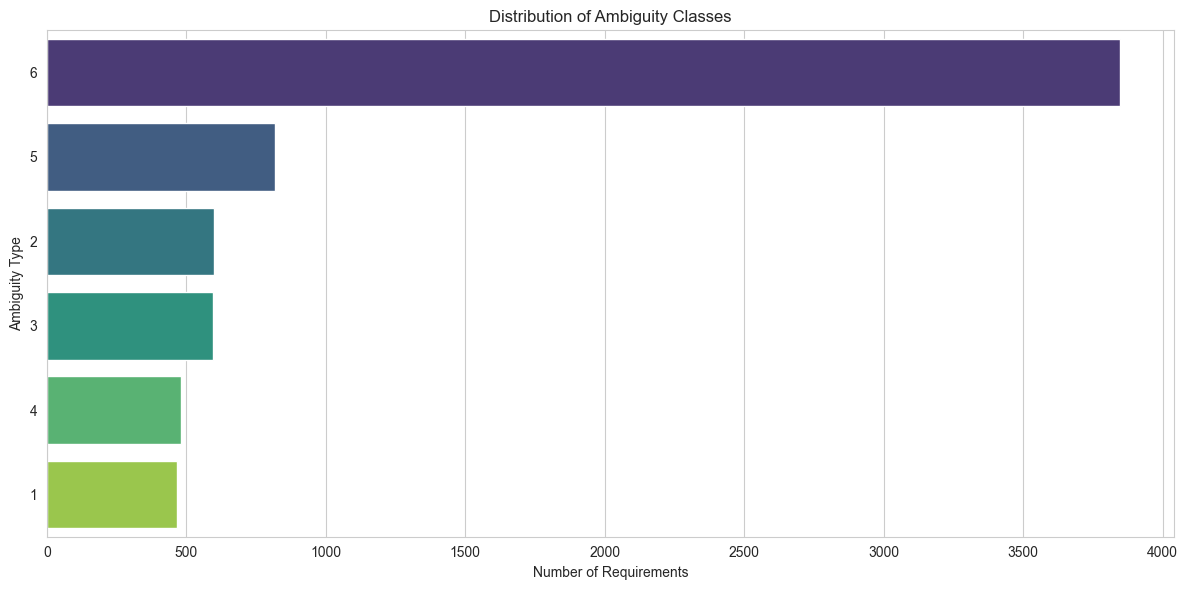


Text Length Statistics:
        char_count   word_count
count  6809.000000  6809.000000
mean    117.155236    18.478778
std     114.294962    18.087670
min       4.000000     1.000000
25%      62.000000    10.000000
50%      90.000000    14.000000
75%     135.000000    21.000000
max    2619.000000   458.000000


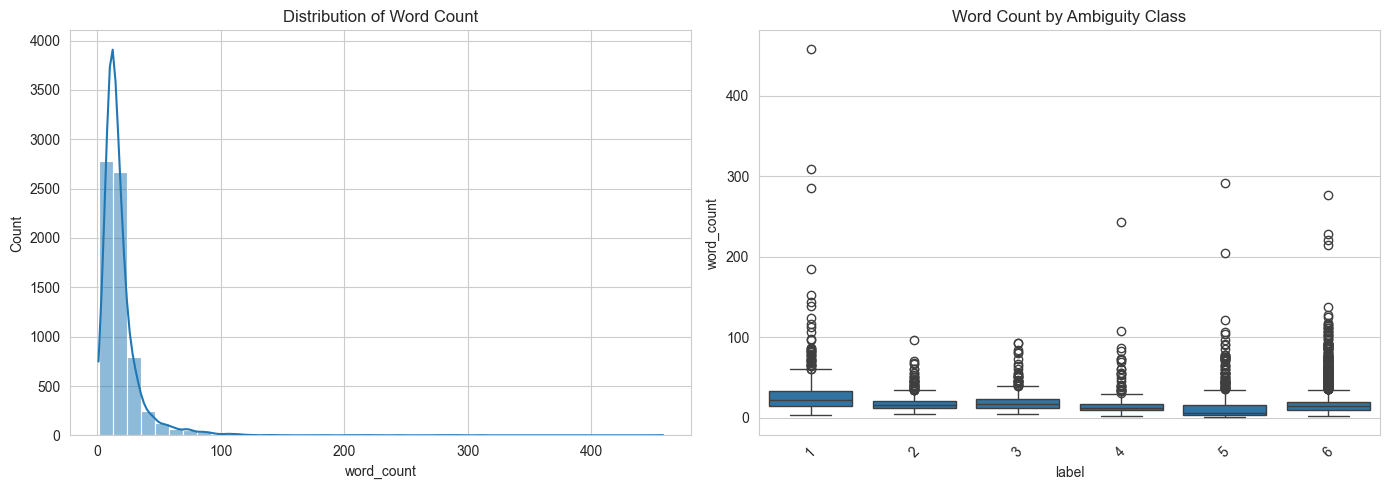

In [ ]:
# ====================== EXPLORATORY DATA ANALYSIS ======================
print("\n Exploratory Data Analysis...")

# Class Distribution Plot
plt.figure()
sns.countplot(data=df, y='label', order=df['label'].value_counts().index, palette='viridis')
plt.title('Distribution of Ambiguity Classes')
plt.xlabel('Number of Requirements')
plt.ylabel('Ambiguity Type')
plt.tight_layout()
plt.show()

# Text Length Analysis
df['char_count'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

print("\nText Length Statistics:")
print(df[['char_count', 'word_count']].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['word_count'], bins=40, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Word Count')

sns.boxplot(x='label', y='word_count', data=df, ax=axes[1])
axes[1].set_title('Word Count by Ambiguity Class')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()



In [ ]:
# ====================== 2.LABEL MAPPING ======================
print("\n2. Mapping Labels...")

# Convert numeric labels to string labels 
if df['label'].dtype.kind in 'biuf':   
    print("Detected numeric labels → Converting to text labels")
    label_mapping = {
        0: "Lexical ambiguity",
        1: "Syntactic ambiguity",
        2: "Semantic ambiguity",
        3: "Syntax ambiguity",
        4: "Pragmatic ambiguity",
        5: "Clean",
        6: "Clean"
    }
    df['label'] = df['label'].map(label_mapping).fillna("Clean")

print("Final label distribution:")
print(df['label'].value_counts())


2. Mapping Labels...
Detected numeric labels → Converting to text labels
Final label distribution:
label
Clean                  4667
Semantic ambiguity      599
Syntax ambiguity        596
Pragmatic ambiguity     481
Syntactic ambiguity     466
Name: count, dtype: int64


In [ ]:
# ====================== 3. RULE-BASED BASELINE ======================
print("\n3. Rule-based Baseline...")

df['rule_pred'] = df['text'].apply(rule_based_ambiguity)

print("Sample comparisons (Actual vs Rule-based):")
print(df[['text', 'label', 'rule_pred']].sample(8, random_state=42))

print("\nRule-based Baseline Performance:")
print(classification_report(df['label'], df['rule_pred'], zero_division=0))


3. Rule-based Baseline...
Sample comparisons (Actual vs Rule-based):
                                                   text             label  \
1632  The system shall query the user as to the form...             Clean   
3891  Ability to set reminder for automatic notifica...             Clean   
2115  Ability to have online card applications enter...             Clean   
2404  The users computer system must have the minimu...             Clean   
3260  Ability to provide pre-coded templates for eas...             Clean   
4558  Ability to indicate preventive maintenance wor...  Syntax ambiguity   
3078  System shall utilize "checklist" each of which...             Clean   
763   System shall accept input signals from microph...             Clean   

                rule_pred  
1632                Clean  
3891                Clean  
2115                Clean  
2404                Clean  
3260                Clean  
4558                Clean  
3078  Pragmatic ambiguity  
763         

In [9]:
# ====================== 4. PREPARE DATA FOR RoBERTA ======================
print("\n4. Preparing Data for RoBERTa...")

from datasets import Dataset
from transformers import RobertaTokenizer

# Map labels to integer IDs
df['label_id'] = df['label'].astype(str).str.strip().map(LABEL_MAP)
df = df.dropna(subset=['label_id']).reset_index(drop=True)

print(f"Final usable samples after label mapping: {len(df)}")

# Train / Validation split (80/20)
train_df = df.sample(frac=0.8, random_state=42)
val_df = df.drop(train_df.index)

train_dataset = Dataset.from_pandas(train_df[['text', 'label_id']].rename(columns={'label_id': 'label'}))
val_dataset = Dataset.from_pandas(val_df[['text', 'label_id']].rename(columns={'label_id': 'label'}))

print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")

# Tokenization
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

print("Tokenizing datasets...")
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)

tokenized_train.set_format("torch")
tokenized_val.set_format("torch")

print("Tokenization completed!")




4. Preparing Data for RoBERTa...
Final usable samples after label mapping: 6809
Train size: 5447
Validation size: 1362


Tokenizing datasets...


Map:   0%|          | 0/5447 [00:00<?, ? examples/s]

Map:   0%|          | 0/1362 [00:00<?, ? examples/s]

Tokenization completed!


In [ ]:
# ====================== 5. FINE-TUNE RoBERTA ======================
print("\n5. Fine-tuning RoBERTa... (Light version for testing)")

from transformers import RobertaForSequenceClassification, TrainingArguments, Trainer

model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=6)

training_args = TrainingArguments(
    output_dir="../models/roberta-ambiguity",
    num_train_epochs=2,                    
    per_device_train_batch_size=8,         
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_dir="../logs",
    logging_steps=50,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

print("Starting training (2 epochs, smaller batch size)...")
trainer.train()


5. Fine-tuning RoBERTa... (Light version for testing)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Starting training (2 epochs, smaller batch size)...


c:\Users\forda\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\forda\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\forda\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1362, training_loss=0.9920521489674125, metrics={'train_runtime': 8223.2782, 'train_samples_per_second': 1.325, 'train_steps_per_second': 0.166, 'total_flos': 716608694909952.0, 'train_loss': 0.9920521489674125, 'epoch': 2.0})

In [ ]:
# ====================== 6. EVALUATE AND SAVE MODEL ======================
print("\n6. Final Evaluation & Save Model...")

from transformers.utils.notebook import NotebookProgressCallback

trainer.callback_handler.callbacks = [
    cb for cb in trainer.callback_handler.callbacks 
    if not isinstance(cb, NotebookProgressCallback)
]

if not trainer.state.log_history:
    trainer.state.log_history = [{"epoch": 0, "step": 0}]

print("Running evaluation... (this may take a few minutes on CPU)")
eval_results = trainer.evaluate()

print("\nFinal Evaluation Results:")
print(eval_results)

# ====================== SAVE MODEL ======================
print("\nSaving model...")

trainer.save_model("../models/roberta-ambiguity-final")
tokenizer.save_pretrained("../models/roberta-ambiguity-final")

print("\n Model saved successfully to: ../models/roberta-ambiguity-final")


6. Final Evaluation & Save Model...
Running evaluation... (this may take a few minutes on CPU)


c:\Users\forda\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Final Evaluation Results:
{'eval_loss': 0.8926078081130981, 'eval_accuracy': 0.698237885462555, 'eval_f1': 0.6022386615778028, 'eval_precision': 0.5611817983222156, 'eval_recall': 0.698237885462555, 'eval_runtime': 213.7235, 'eval_samples_per_second': 6.373, 'eval_steps_per_second': 0.8, 'epoch': 2.0}

Saving model...


c:\Users\forda\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Model saved successfully to: ../models/roberta-ambiguity-final


In [13]:
# ====================== 7. QUICK INFERENCE TEST ======================
print("\n7. Quick Inference Test...")

import torch
from src.model import AmbiguityRoBERTa

# Load the trained model
model_obj = AmbiguityRoBERTa()
model_obj.model = model_obj.model.from_pretrained("../models/roberta-ambiguity-final")
model_obj.tokenizer = model_obj.tokenizer.from_pretrained("../models/roberta-ambiguity-final")
model_obj.model.eval()

inverse_map = {v: k for k, v in LABEL_MAP.items()}

def predict_ambiguity(text: str):
    # Hybrid: Rule-based first
    rule = rule_based_ambiguity(text)
    if rule != "Clean":
        return rule
    
    # RoBERTa prediction
    inputs = model_obj.tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
    with torch.no_grad():
        outputs = model_obj.model(**inputs)
    pred_id = outputs.logits.argmax(-1).item()
    return inverse_map.get(pred_id, "Unknown")

# Test examples
test_examples = [
    "The system shall process some data quickly when possible.",
    "The user may login using email or phone number.",
    "All valid users must be able to access the report.",
    "The software should handle a large number of requests."
]

print("\nInference Examples:")
for example in test_examples:
    result = predict_ambiguity(example)
    print(f"Text: {example}")
    print(f"Predicted: {result}\n")

print("Exploration and Training completed successfully!")


7. Quick Inference Test...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Inference Examples:
Text: The system shall process some data quickly when possible.
Predicted: Lexical ambiguity

Text: The user may login using email or phone number.
Predicted: Pragmatic ambiguity

Text: All valid users must be able to access the report.
Predicted: clean

Text: The software should handle a large number of requests.
Predicted: Pragmatic ambiguity

Exploration and Training completed successfully!
